<a href="https://colab.research.google.com/github/SvetaTrusova/LR2_Data_visualisation/blob/main/labs/%D0%9B%D0%A03_%D0%9E%D0%B1%D0%B5%D1%81%D0%BF%D0%B5%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BA%D0%B0%D1%87%D0%B5%D1%81%D1%82%D0%B2%D0%B0_%D0%B4%D0%B0%D0%BD%D0%BD%D1%8B%D1%85.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Постановка задачи


**Цель работы:** исследование и обработка данных для повышения их качества.

**Краткое описание:** в лабораторной работе приводится поэтапный план изучения и обработки намеренно не предобработанных данных. Необходимо выполнить все этапы плана и оценить результаты преобразований.

# Данные



В папке [Data/lab3](https://drive.google.com/drive/folders/1437z7m5Ut4WUJOhJg1oZz13dtBpxgFKs?usp=share_link) расположена таблица `monster_com_job_sample.com` с данными о вакансиях. Также эти данные с описанием и примерами обработки можно найти на [kaggle](https://www.kaggle.com/code/ankkur13/perfect-dataset-to-get-the-hands-dirty/data#).

##### **Формат данных**

```
country,country_code,date_added,has_expired,job_board,job_description,job_title,job_type,location,organization,page_url,salary,sector,uniq_id
United States of America,US,"",No,jobs.monster.com,"TeamSoft is seeing an IT Support Specialist to join our client in Madison, WI. The ideal candidate must have at least 6 years of experience in the field. They need to be familiar with a variety of the field's concepts, practices, and procedures as this position relies on extensive experience and judgment to plan and accomplish goals. Required Skills:вАҐ Call tracking softwareвАҐ Phone based technical supportвАҐ Problem documentation and communicationвАҐ Remote Desktop Management ToolsвАҐ Respond to customer requestsвАҐ General understanding of LANDeskвАҐ Microsoft Office 2007 SuiteFind out why TeamSoft is the Madison area's technology leader with over 200 IT consultants. Owned, operated, and managed by IT consultants, TeamSoft is the clear choice for your career. Join the TeamSoft family today!Did you know?вАҐ TeamSoft offers salaried options for many positions that include 5 weeks PTO and great benefits!вАҐ TeamSoft has been in business since 1996вАҐ TeamSoft's owners are local IT professionals who possess a wealth of experience in application development, business analysis, and project managementвАҐ TeamSoft's Recruiters are knowledgeable, friendly, and ready to help you make your next great career moveвАҐ TeamSoft offers a full benefits suite to all of our W2 consultants, including a 401k plan with a 100% vested 4% dollar for dollar matchвАҐ Our targeted selection process is designed to get to know your strengths and career interests and provide you with the best chance for success in your new positionвАҐ Our longest running consultant has been with us for 16 yearsвАҐ Consultants can participate in our charitable giving committee. To date, TeamSoft's charitable giving committee has donated over $100,000!TeamSoft is owned by local IT professionals. Our team also has deep experience with IT staffing. Our clients understand this and rely on our expertise. That is why TeamSoft is the Madison Area's largest privately owned IT consulting firm, with more than 200 current consultants! With over 50 active clients, TeamSoft will give you the greatest exposure to the widest range of IT careers.Our owners possess a combined 60+ years of IT consulting experience. Our recruiting and Account Management staff are very well-versed in our client markets. We get you. We know you. We know what you do every day. And we know what you deal with on the job.You take your career seriously and so do we. At TeamSoft you are not just a resume or number. Our goal is to create long-term partnerships with each of our consultants, and according to feedback from many of them, we are very good at this. Click HERE to see what our consultants have to say about working with TeamSoft.TeamSoft -- Promote yourself!TeamSoft is an equal employment opportunity employer functioning under an Affirmative Action Plan.",IT Support Technician Job in Madison,Full Time Employee,"Madison, WI 53702","",http://jobview.monster.com/it-support-technician-job-madison-wi-us-167855963.aspx?mescoid=1500134001001&jobPosition=20,"",IT/Software Development,11d599f229a80023d2f40e7c52cd941e
United States of America,US,"",No,jobs.monster.com,"The Wisconsin State Journal is seeking a flexible and motivated reporter/editor to lead its three-person business desk. WeвАЩre looking for an experienced journalist able to spot trends, be a watchdog and reflect the Madison areaвАЩs vibrant entrepreneurial community. This is a hybrid reporting and editing position that calls for a fleet-footed, multimedia storyteller able to maximize the newspaperвАЩs online presentation while also editing two sections a week. Candidates must have strong news judgment, be well versed in business news and trends and be able to quickly prioritize coverage.At least five yearsвАЩ experience reporting or editing for digital and print platforms desired. To be considered for the position, applicants must apply online.¬†As part of your online application, please attach five samples of your work or links to five recent stories.Wisconsin State Journal, 1901 Fish Hatchery Road, Madison, WI 53713Affirmative Action/Equal Opportunity Employer/Pre-employment drug testing appliesPI94338362Apply Here",Business Reporter/Editor Job in Madison,Full Time,"Madison, WI 53708",Printing and Publishing,http://jobview.monster.com/business-reporter-editor-job-madison-wi-us-167830105.aspx?mescoid=2700437001001&jobPosition=7,"","",e4cbb126dabf22159aff90223243ff2a
...
```

##### **Описание полей**
 - ```country``` — наименование страны;
 - ```country_code``` — код страны;
 - ```date_added``` — дата размещения вакансии;
 - ```has_expired``` — актуальность вакансии;
 - ```job_board``` — агрегатор вакансий, с которого собраны данные;
 - ```job_description``` — описание вакансии;
 - ```job_title``` — наименование должности;
 - ```job_type``` — вид занятости;
 - ```location``` — метоположение организации;
 - ```organization``` — наименование организации;
 - ```page_url``` — ссылка на страницу с вакансией;
 - ```salary``` — заработная плата;
 - ```sector``` — сфера деятельности;
 - ```uniq_id``` — уникальный идентификатор записи о вакансии.

# Понимание данных

In [4]:
import re
import numpy as np
import pandas as pd
import missingno as msno
from matplotlib import pyplot as plt
import seaborn as sns
from google.colab import files
import io

uploaded = files.upload()
df = pd.read_csv(io.BytesIO(uploaded['monster_com_job_sample.csv']))
print(f"✅ Данные загружены. Размер: {df.shape[0]} строк, {df.shape[1]} столбцов")


Saving monster_com_job_sample.csv to monster_com_job_sample.csv
✅ Данные загружены. Размер: 22000 строк, 14 столбцов


В датасете есть несколько столбцов, в каждой ячейке которых записано одно и то же значение. Есть столбцы, в которых формат записи значений не стандартизирован. А есть такие, где указана информация, не соответствующая названию столбца.

**Первый этап изучения данных** – понять, какие основные проблемы предстоит решить для каждого из столбцов. Для этого загрузите датасет и выведите случайные несколько строк из него. Постарайтесь понять, что из себя представляют данные в столбцах.

In [8]:
print("СЛУЧАЙНЫЕ 10 СТРОК:")
print(df.sample(10))

print("\nИНФОРМАЦИЯ О СТОБЦАХ:")
print(df.info())

СЛУЧАЙНЫЕ 10 СТРОК:
                        country country_code date_added has_expired  \
20165  United States of America           US        NaN          No   
10609  United States of America           US        NaN          No   
2301   United States of America           US        NaN          No   
12847  United States of America           US        NaN          No   
16028  United States of America           US        NaN          No   
19450  United States of America           US        NaN          No   
8549   United States of America           US        NaN          No   
5559   United States of America           US        NaN          No   
8862   United States of America           US        NaN          No   
18576  United States of America           US        NaN          No   

              job_board                                    job_description  \
20165  jobs.monster.com  15P Aviation Operations Specialist Job ID: 774...   
10609  jobs.monster.com  SR. QA ASSOCIATE 

**Задание**

Составьте таблицу, в которой будет содержаться название столбца, тип данных в нем и краткое описание проблем, которые вы заметили при первом взгляде на данные.


| Название столбца | Тип данных | Проблемы |
|-----------------|------------|----------|
| country | object | Все значения одинаковые ("United States of America") - можно удалить |
| country_code | object | Все значения одинаковые ("US") - можно удалить |
| date_added | object | Почти все значения NaN, нестандартный формат даты|
| has_expired | object | Все значения "No" - избыточный столбец |
| job_board | object | Все значения "jobs.monster.com" - константа |
| job_description | object | Длинный текст, есть HTML-теги, спецсимволы |
| job_title | object | Содержит город в названии (Job in City), дублирует location |
| job_type | object | Разные форматы: "Full Time Employee", "Full Time, Employee", "Full Time" и т.д. |
| location | object | Разные форматы: "Город, ШТ", "Город, ШТ Индекс", только "Город" |
| organization | object | Много NaN, иногда содержит несколько значений через пробел |
| page_url | object | Уникальные URL для каждой вакансии |
| salary | object | Разные форматы: диапазоны, "Up to...", единичные значения, много NaN |
| sector | object | Много NaN, иногда содержит организацию |
| uniq_id | object | Уникальные идентификаторы (нужно проверить уникальность) |

### Оценка пустых ячеек в датасете

Выясните, в каких столбцах, строках и в каком количестве отсутствуют данные:
1. С помощью модуля `pandas` составьте таблицу, где каждому названию столбца будет сопоставлено общее количество ячеек и количество пустых ячеек.
2. Подсчитайте количество строк датасета, в которых пустыми являются более 75% ячеек.
3. Визуализируйте число пропусков в датасете с помощью модуля, построив столбчатую диаграмму. Для удобства можно воспользоваться модулем `missingno`.


Название столбца Тип данных  Всего ячеек  Количество пустых ячеек  Процент пустых (%)
         country     object        22000                        0                0.00
    country_code     object        22000                        0                0.00
      date_added     object        22000                    21878               99.45
     has_expired     object        22000                        0                0.00
       job_board     object        22000                        0                0.00
 job_description     object        22000                        0                0.00
       job_title     object        22000                        0                0.00
        job_type     object        22000                     1628                7.40
        location     object        22000                        0                0.00
    organization     object        22000                     6867               31.21
        page_url     object        22000              

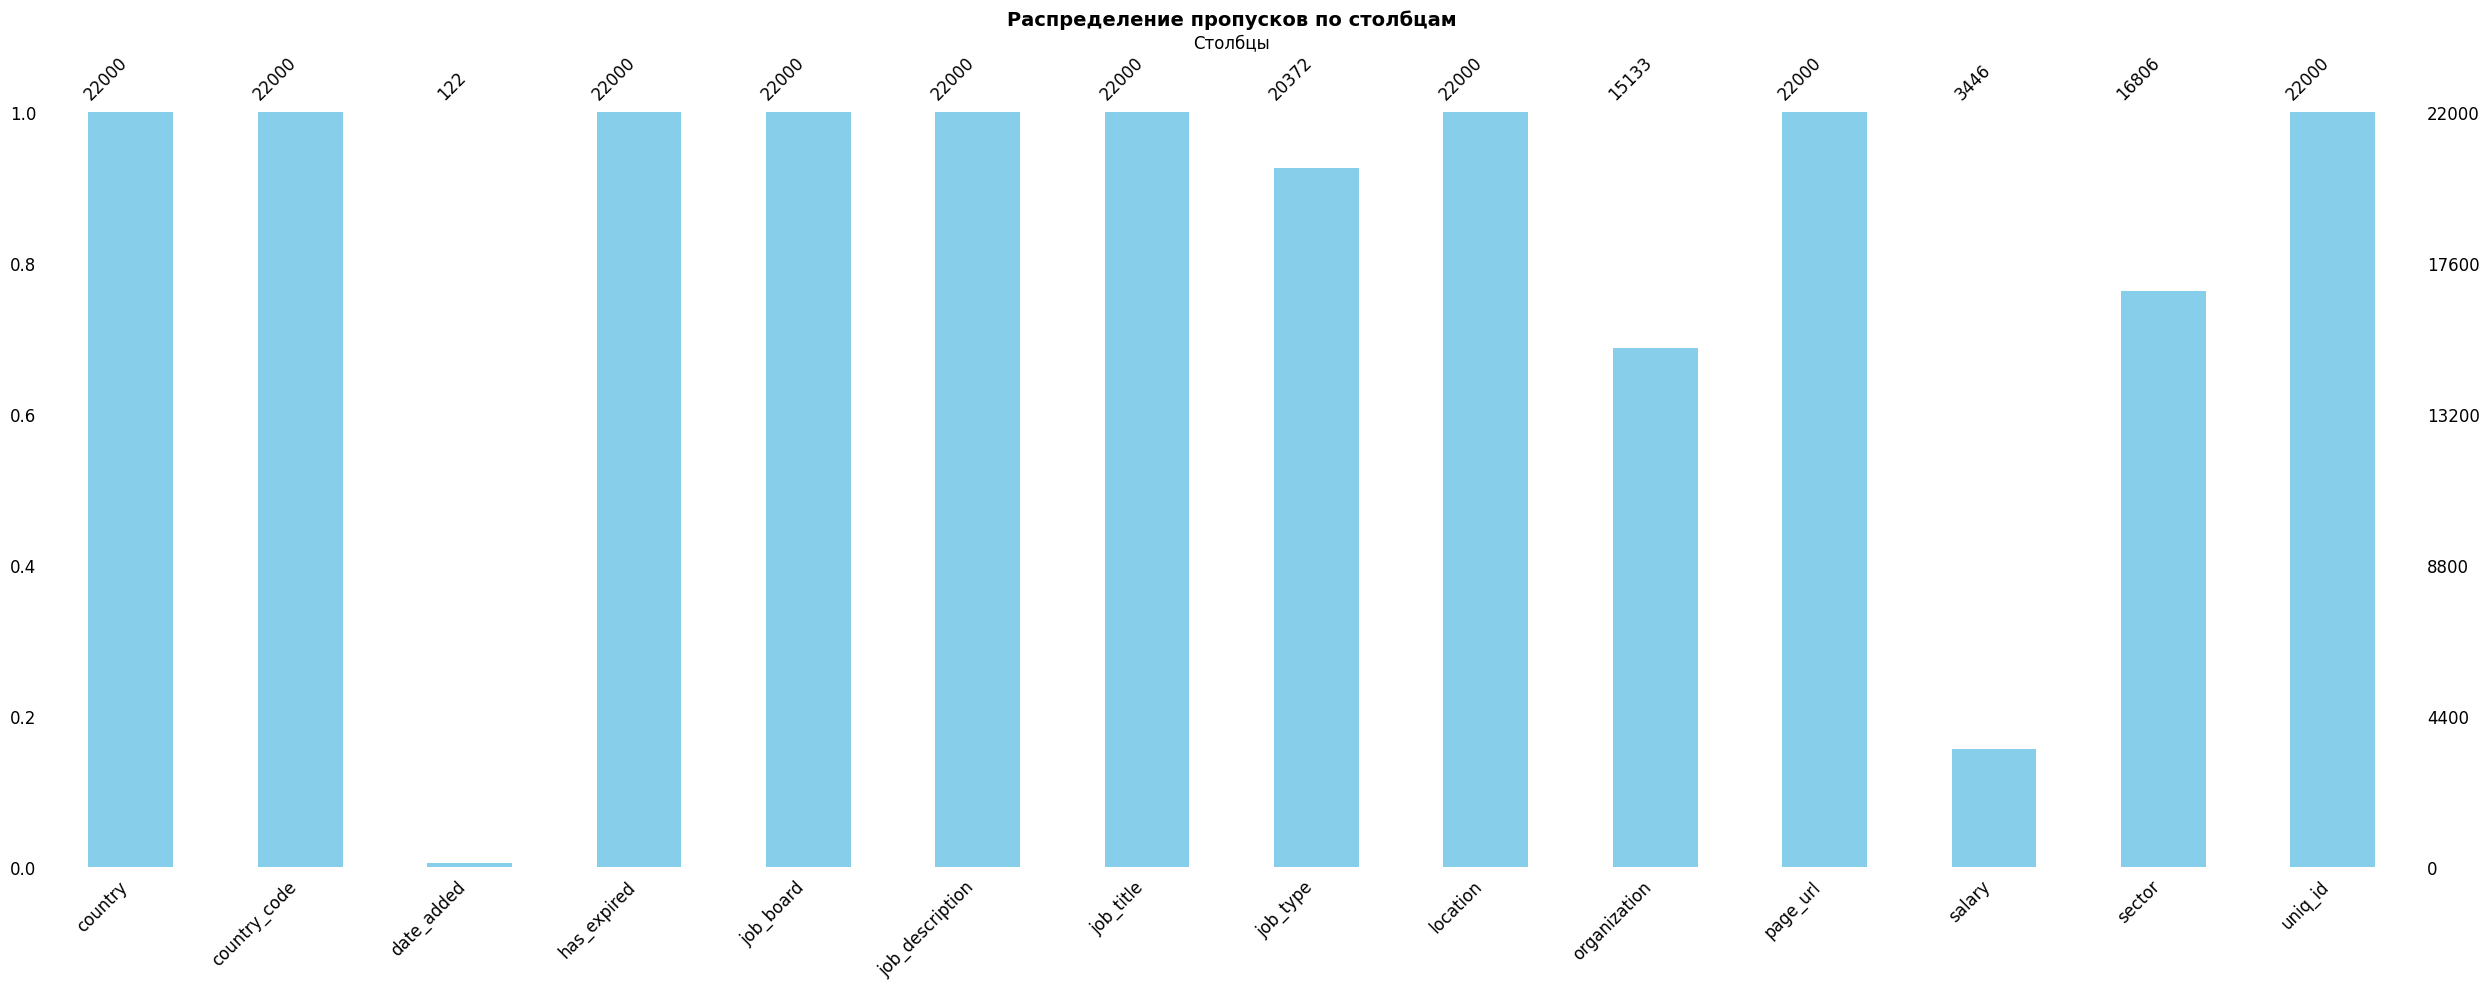

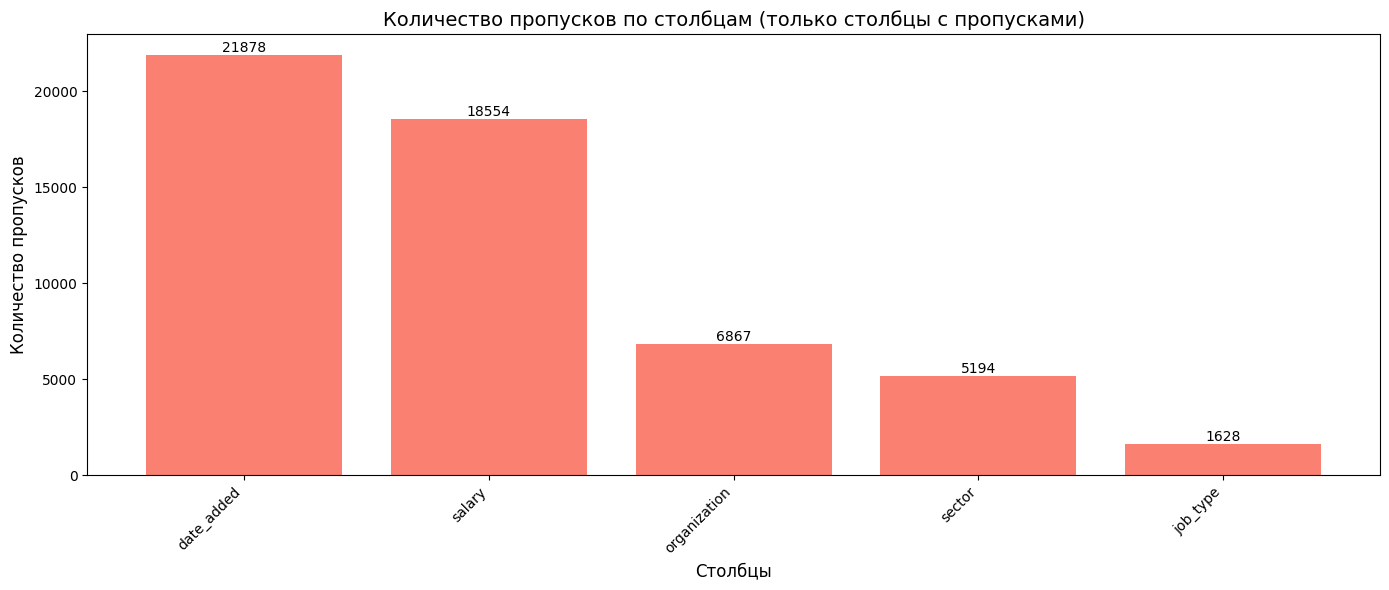

In [19]:
#1 таблица анализа пропусков по столбцам
empty_table = pd.DataFrame({
    'Название столбца': df.columns,
    'Тип данных': df.dtypes.values,
    'Всего ячеек': len(df),
    'Количество пустых ячеек': df.isnull().sum().values,
    'Процент пустых (%)': (df.isnull().sum().values / len(df) * 100).round(2)
})

print(empty_table.to_string(index=False))

#2 Количество строк, где пустыми являются более 75% ячеек

# Преобразуем пустые строки '' в NaN (если они есть)
df_temp = df.replace('', pd.NA)

# Считаем количество пустых ячеек в каждой строке
nulls_per_row = df_temp.isnull().sum(axis=1)

# Порог: 75% от количества столбцов
threshold = 0.75 * len(df.columns)

# Количество строк, где пустых >75%
rows_with_many_nulls = (nulls_per_row > threshold).sum()

print(f"Всего столбцов в датасете: {len(df.columns)}")
print(f"Пороговое значение (75% от {len(df.columns)}): {threshold:.1f} пустых ячеек")
print(f"Количество строк с >{threshold:.0f} пустых ячеек: {rows_with_many_nulls}")
print(f"Процент от всех строк: {(rows_with_many_nulls / len(df)) * 100:.2f}%")

#3 Визуализация пропусков
# Столбчатая диаграмма с помощью missingno
plt.figure(figsize=(14, 6))
msno.bar(df, color='skyblue', fontsize=12)
plt.title('Распределение пропусков по столбцам', fontsize=14, fontweight='bold')
plt.xlabel('Столбцы', fontsize=12)
plt.ylabel('Количество непустых значений', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Альтернативная визуализация (своя, для наглядности)
plt.figure(figsize=(14, 6))
missing_counts = df.isnull().sum()
missing_counts = missing_counts[missing_counts > 0].sort_values(ascending=False)

if len(missing_counts) > 0:
    bars = plt.bar(missing_counts.index, missing_counts.values, color='salmon')
    plt.title('Количество пропусков по столбцам (только столбцы с пропусками)', fontsize=14)
    plt.xlabel('Столбцы', fontsize=12)
    plt.ylabel('Количество пропусков', fontsize=12)
    plt.xticks(rotation=45, ha='right')

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}',
                 ha='center', va='bottom', fontsize=10)

    plt.tight_layout()
    plt.show()
else:
    print("Нет столбцов с пропусками!")



Проверьте, как изменится размер датасета, если принять решение удалить все строки, где есть пустые значения. Сделайте выводы.

In [22]:
# Исходный размер
original_rows = len(df)
original_cols = len(df.columns)

print(f"\nИСХОДНЫЙ ДАТАСЕТ:")
print(f"   • Количество строк: {original_rows}")
print(f"   • Количество столбцов: {original_cols}")
print(f"   • Общее количество ячеек: {original_rows * original_cols}")

# Преобразуем пустые строки '' в NaN (для корректного подсчета)
df_temp = df.replace('', pd.NA)

# Удаляем все строки, где есть хотя бы одно пустое значение
df_dropped = df_temp.dropna()

# Новый размер
new_rows = len(df_dropped)
new_cols = len(df_dropped.columns)

print(f"\nПОСЛЕ УДАЛЕНИЯ СТРОК С ПУСТЫМИ ЗНАЧЕНИЯМИ:")
print(f"   • Количество строк: {new_rows}")
print(f"   • Количество столбцов: {new_cols}")
print(f"   • Осталось ячеек: {new_rows * new_cols}")

# Потери
rows_lost = original_rows - new_rows
rows_lost_percent = (rows_lost / original_rows) * 100

print(f"\nПОТЕРИ ДАННЫХ:")
print(f"   • Удалено строк: {rows_lost} из {original_rows}")
print(f"   • Потеряно процентов строк: {rows_lost_percent:.1f}%")


ИСХОДНЫЙ ДАТАСЕТ:
   • Количество строк: 22000
   • Количество столбцов: 14
   • Общее количество ячеек: 308000

ПОСЛЕ УДАЛЕНИЯ СТРОК С ПУСТЫМИ ЗНАЧЕНИЯМИ:
   • Количество строк: 5
   • Количество столбцов: 14
   • Осталось ячеек: 70

ПОТЕРИ ДАННЫХ:
   • Удалено строк: 21995 из 22000
   • Потеряно процентов строк: 100.0%


УДАЛЕНИЕ ВСЕХ СТРОК С ПУСТЫМИ ЗНАЧЕНИЯМИ НЕЦЕЛЕСООБРАЗНО!

Причина: будет удалено 100.0% всех строк (21995 из 22000). В датасете останется только 5 строк, а это слишком большая потеря данных для анализа

РЕКОМЕНДАЦИИ:
   1. Не удалять строки с пропусками в salary (18554 пустых, 84.3%)
      — это ценная информация, даже если не у всех вакансий указана зарплата
   
   2. Удалить столбец date_added (21878 пустых, 99.4%)
      — он почти полностью пустой и бесполезен
   
   3. Для job_type (1628 пустых, 7.4%)
      — заполнить пропуски значением "Unknown"
   
   4. Для organization (6867 пустых, 31.2%)
      — оставить как есть или заполнить "Not specified"

### Первичная оценка данных в столбцах

Изучите данные в столбцах датасета, ответив на следующие вопросы:
1. Есть ли столбцы, в которых встречается всего одно значение? Как их можно использовать в анализе?
2. Есть ли такие значения, которые встречаются более чем в одном столбце?
3. Есть ли столбцы, данные в которых не соответствуют названию столбца?

In [32]:
# ВОПРОС 1: Столбцы, в которых встречается всего одно значение
print("ВОПРОС 1: СТОЛБЦЫ С ОДНИМ ЗНАЧЕНИЕМ")
cols_with_one_value = []
for col in df.columns:
    unique_count = df[col].nunique()
    if unique_count == 1:
        cols_with_one_value.append(col)
        print(f"\n• {col}:")
        print(f"   Уникальных значений: {unique_count}")
        print(f"   Значение: '{df[col].iloc[0]}'")

if cols_with_one_value:
    print(f"\nСТОЛБЦЫ С ОДНИМ ЗНАЧЕНИЕМ: {cols_with_one_value}")
else:
    print("\nСтолбцов с одним значением не найдено")

# ВОПРОС 2: Значения, которые встречаются более чем в одном столбце

print("ВОПРОС 2: ЗНАЧЕНИЯ, ВСТРЕЧАЮЩИЕСЯ В НЕСКОЛЬКИХ СТОЛБЦАХ")

# Выбираем текстовые столбцы для сравнения
text_cols = df.select_dtypes(include=['object']).columns
print(f"Анализируем {len(text_cols)} текстовых столбцов")

# Проверяем конкретные пары столбцов, где могут быть дублирования
pairs_to_check = [
    ('job_title', 'location'),
    ('organization', 'sector'),
    ('job_type', 'employment_type'),
]

for col1, col2 in pairs_to_check:
    if col1 in df.columns and col2 in df.columns:
        common_values = set(df[col1].dropna().unique()) & set(df[col2].dropna().unique())
        if common_values:
            print(f"\n• {col1} и {col2}:")
            print(f"   Общие значения: {list(common_values)[:5]}")
            if len(common_values) > 5:
                print(f"   ... и еще {len(common_values) - 5} значений")

# Проверяем, есть ли значения location внутри job_title
print("\nАнализ: Есть ли город в названии должности?")
sample_df = df[['job_title', 'location']].dropna().head(20)
found_examples = 0
for idx, row in sample_df.iterrows():
    job_title = str(row['job_title']).lower()
    location = str(row['location']).lower()
    # Извлекаем город из location (до запятой или пробела)
    if ',' in location:
        city = location.split(',')[0].strip()
    else:
        city = location.split()[0] if location else ''

    if city and city.lower() in job_title.lower() and len(city) > 2:
        found_examples += 1
        if found_examples <= 5:
            print(f"   Пример: в job_title найдено '{city}' из location")

if found_examples > 0:
    print(f"\n   ✅ Найдено {found_examples} примеров дублирования города в job_title")
else:
    print("   ❌ Примеров не найдено")

# ВОПРОС 3: Столбцы, данные в которых не соответствуют названию

print("ВОПРОС 3: СТОЛБЦЫ С НЕСООТВЕТСТВУЮЩИМИ ДАННЫМИ")

# Список настоящих штатов США (для проверки)
US_STATES = {
    'AL', 'AK', 'AZ', 'AR', 'CA', 'CO', 'CT', 'DE', 'FL', 'GA',
    'HI', 'ID', 'IL', 'IN', 'IA', 'KS', 'KY', 'LA', 'ME', 'MD',
    'MA', 'MI', 'MN', 'MS', 'MO', 'MT', 'NE', 'NV', 'NH', 'NJ',
    'NM', 'NY', 'NC', 'ND', 'OH', 'OK', 'OR', 'PA', 'RI', 'SC',
    'SD', 'TN', 'TX', 'UT', 'VT', 'VA', 'WA', 'WV', 'WI', 'WY',
    'DC', 'PR', 'GU', 'VI', 'AS', 'MP'
}

# 1. Проверка job_title: содержит ли город (признак " in ")

print("\n1. АНАЛИЗ СТОЛБЦА 'job_title':")

# Количество строк, где job_title содержит " in " (признак города)
titles_with_city = df[df['job_title'].str.contains(' in ', na=False)].shape[0]
total_titles = df['job_title'].notna().sum()
percent_with_city = (titles_with_city / total_titles) * 100

print(f"   • Всего непустых job_title: {total_titles}")
print(f"   • Содержат ' in ' (признак города): {titles_with_city}")
print(f"   • Процент: {percent_with_city:.1f}%")

# 2. Проверка salary: является ли текстовым (должен быть числовым)

print("\n2. АНАЛИЗ СТОЛБЦА 'salary':")

total_salary = df['salary'].notna().sum()
empty_salary = df['salary'].isna().sum()
percent_empty = (empty_salary / len(df)) * 100

# Проверяем, сколько строк содержат числа (потенциально корректные)
salary_with_numbers = df['salary'].astype(str).str.contains(r'\d', na=False).sum()

print(f"   • Всего строк с salary: {total_salary}")
print(f"   • Пустых salary: {empty_salary} ({percent_empty:.1f}% от всего датасета)")
print(f"   • Содержат цифры: {salary_with_numbers} из {total_salary}")

# 3. Проверка organization: содержит ли несколько значений

print("\n3. АНАЛИЗ СТОЛБЦА 'organization':")

total_org = df['organization'].notna().sum()
empty_org = df['organization'].isna().sum()
percent_empty_org = (empty_org / len(df)) * 100

# Строки с очень длинным значением (возможно, несколько организаций)
long_org = df[df['organization'].astype(str).str.len() > 100].shape[0]

print(f"   • Всего непустых organization: {total_org}")
print(f"   • Пустых organization: {empty_org} ({percent_empty_org:.1f}%)")
print(f"   • Содержат >100 символов (возможно, несколько значений): {long_org}")

# 4. Проверка sector и organization: не дублируются ли они

print("\n4. АНАЛИЗ ПЕРЕСЕЧЕНИЙ 'sector' И 'organization':")

# Количество строк, где sector содержится в organization
sector_in_org = 0
# Количество строк, где organization содержится в sector
org_in_sector = 0

# Берем только строки, где оба поля непустые
both_nonempty = df[df['sector'].notna() & df['organization'].notna()]

for idx, row in both_nonempty.iterrows():
    sector = str(row['sector'])
    org = str(row['organization'])
    if len(sector) > 3 and sector in org:
        sector_in_org += 1
    if len(org) > 3 and org in sector:
        org_in_sector += 1

print(f"   • Строк с заполненными обоими полями: {len(both_nonempty)}")
print(f"   • sector содержится в organization: {sector_in_org}")
print(f"   • organization содержится в sector: {org_in_sector}")

# 5. Проверка location: на наличие мусора (не адреса)

print("\n5. АНАЛИЗ СТОЛБЦА 'location':")

# Проверка на наличие некорректных данных в location
total_loc = len(df)
non_empty_loc = df['location'].notna().sum()

# Проверка: есть ли в location явные признаки мусора
garbage_patterns = r'Job Description|Description|Phone|Contact|http|@|Job Number|Kindred|Forever 21'
garbage_in_loc = df[df['location'].astype(str).str.contains(garbage_patterns, na=False, regex=True)]
count_garbage = len(garbage_in_loc)

print(f"Всего строк: {total_loc}")
print(f"Непустых значений в location: {non_empty_loc}")
print(f"Строк с явными признаками мусора в location: {count_garbage} ({count_garbage/total_loc*100:.1f}%)")

# Проверка: какие форматы location (наличие запятой, индекса, штата)
has_comma = df['location'].astype(str).str.contains(',', na=False).sum()
has_zip = df['location'].astype(str).str.contains(r'\d{5}', na=False, regex=True).sum()
has_state = df['location'].astype(str).str.contains(r'\b[A-Z]{2}\b', na=False, regex=True).sum()

print(f"\nСтрок с запятой (признак формата 'Город, ШТ'): {has_comma} ({has_comma/total_loc*100:.1f}%)")
print(f"Строк с почтовым индексом (5 цифр): {has_zip} ({has_zip/total_loc*100:.1f}%)")
print(f"Строк с кодом штата (2 заглавные буквы): {has_state} ({has_state/total_loc*100:.1f}%)")

# 6. ПРОВЕРКА job_type (нестандартизированные форматы)

print("6. ПРОВЕРКА СТОЛБЦА 'job_type'")

total_jt = len(df)
non_empty_jt = df['job_type'].notna().sum()
empty_jt = df['job_type'].isna().sum()

print(f"Всего строк: {total_jt}")
print(f"Непустых значений в job_type: {non_empty_jt}")
print(f"Пустых значений в job_type: {empty_jt}")

# Анализ уникальных значений job_type
unique_jt = df['job_type'].dropna().unique()
print(f"\nКоличество уникальных форматов job_type: {len(unique_jt)}")
print("Примеры различных форматов (первые 10):")
for jt in unique_jt[:10]:
    print(f"  • {jt}")

ВОПРОС 1: СТОЛБЦЫ С ОДНИМ ЗНАЧЕНИЕМ

• country:
   Уникальных значений: 1
   Значение: 'United States of America'

• country_code:
   Уникальных значений: 1
   Значение: 'US'

• has_expired:
   Уникальных значений: 1
   Значение: 'No'

• job_board:
   Уникальных значений: 1
   Значение: 'jobs.monster.com'

СТОЛБЦЫ С ОДНИМ ЗНАЧЕНИЕМ: ['country', 'country_code', 'has_expired', 'job_board']
ВОПРОС 2: ЗНАЧЕНИЯ, ВСТРЕЧАЮЩИЕСЯ В НЕСКОЛЬКИХ СТОЛБЦАХ
Анализируем 14 текстовых столбцов

• job_title и location:
   Общие значения: ['Project Manager', 'RF Engineer', 'Job Details', 'Senior Accountant', 'Software Engineer']
   ... и еще 7 значений

• organization и sector:
   Общие значения: ['Retail', 'Electrical/Electronics EngineeringIndustrial/Manufacturing EngineeringMechanical Engineering']

Анализ: Есть ли город в названии должности?
   Пример: в job_title найдено 'madison' из location
   Пример: в job_title найдено 'madison' из location
   Пример: в job_title найдено 'dixon' из location
   Пр

Вопрос 1

столбцы с одним значением:СТОЛБЦЫ С ОДНИМ ЗНАЧЕНИЕМ: country, country_code, has_expired, job_board

КАК ИХ МОЖНО ИСПОЛЬЗОВАТЬ В АНАЛИЗЕ?
   - Эти столбцы НЕ НЕСУТ информации для анализа
   - Они не помогут различить разные вакансии
   - ИХ МОЖНО УДАЛИТЬ без потери данных
   - Исключение: если нужно знать, что все данные из США

Вопрос 2

📌 ВЫВОД 1: Столбцы с одним значением
   → country, country_code, has_expired, job_board
   → Это константные столбцы, они не несут информации
   → ИХ МОЖНО УДАЛИТЬ без потери данных

📌 ВЫВОД 2: Значения, встречающиеся в нескольких столбцах
   → Города из location часто дублируются в job_title (например, "Job in Madison")
   → Это избыточность данных, job_title нужно очистить от названий городов

📌 ВЫВОД 3: Столбцы с несоответствием названию
   → job_title: содержит город (не только должность)
   → salary: текстовый формат, нужно парсить числа
   → organization и sector: иногда перепутаны или содержат лишние данные

### Дублирование данных

Для поиска дублирующихся строк выполните следующие действия:
1. В таблице есть столбец `uniq_id`, значения которого, как сказано в описании данных, являются уникальными идентификаторами записей. Проверьте, действительно ли в этом столбце все значения различны.
2. Проверьте, есть ли в таблице другие столбцы, значения которых в каждой строке различны.
3. Если игнорировать столбцы, где все значения различны, найдутся ли такие строки, для которых значения по всем остальным столбцам будут совпадать?

Оцените результаты поиска дубликатов.

In [ ]:
# PUT YOUR CODE HERE

# Практические задания

В этом разделе необходимо обработать значения в трех столбцах датасета: `location`, `salary` и `job_type`. Цель обработки – стандартизировать данные в каждом из столбцов так, чтобы их можно было анализировать.

### Задание 1

В задании 1 необходимо провести обработку столбца `location`.

#### Задание 1.1

В столбце `location` представлена информация о местоположении организации, в которой открыта вакансия. Каждое значение столбца `location` содержит информацию о городе, коде штата и почтовом индексе.

Однако не в каждой строке есть все три характеристики местоположения, а также могут встречаться разные комбинации из них, записанные в виде строки в произвольном порядке и с разными разделителями.

Например, может быть указан только код штата, только название города или только индекс. Могут быть указаны любые две характеристики из трех.

**Формулировка задания:**
1. Определите, какие форматы встречаются.
2. Напишите одно или несколько регулярных выражений для поиска выявленных форматов.
3. Визуализируйте количество найденных форматов на столбчатой или круговой диаграмме. Также покажите на ней количество строк, в которых формат определить не удалось. Какие форматы встречаются чаще всего?

Ознакомиться с теоретическим материалом по работе с регулярными выражениями можно [по ссылке](https://colab.research.google.com/drive/1eFHdmt9OROLEDJRNc2wNmz0gpE1O3sKU?usp=sharing).

In [ ]:
# PUT YOUR CODE HERE

#### Задание 1.2

В большей части строк удалось извлечь данные из ячейки столбца `location`, но остались и такие, где это не получилось. Вынесите в отдельный датасет записи, в которых не удалось определить формат записи информации о местоположении.

Над оставшимися строками проведите следующие преобразования:
1. Данные о местоположении разделите на 3 столбца: город, код штата, почтовый индекс.
2. Так как значения в столбце `почтовый индекс` являются пятизначными числами, преобразуйте их в целочисленный формат.

In [ ]:
# PUT YOUR CODE HERE

Рассмотрите отложенную часть выборки (ту, где не удалось данные из столбца `location` разделить на три поля) и сделайте выводы о возможности извлечь из данных город, код штата и почтовый индекс. Извлеките все, что возможно. Что невозможно – оставьте пустым.

In [ ]:
# PUT YOUR CODE HERE

### Задание 2

В задании 2 необходимо провести обработку столбца `salary`.

#### Задание 2.1

В столбце `salary`, как и в `location`, данные не стандатизированы. В нем в основном можно встретить записи в следующих форматах:

* 10.00 - 20.00 &dollar; &sol;hour
* 10,000.00 - 20,000.00 &dollar; &sol;year
* &dollar;10.00 &sol;hour
* &dollar;10,000.00+ &sol;year
* Up to &dollar;20,000.00

Основные проблемы, которые стоит учесть при обработке форматов:
- В каждом из форматов может быть или не быть знака доллара.
- Может отсутствовать информация о периоде, за который указывается зарплата (`/hour` или `/year` в примерах).
- Зарплата может быть указана за месяц (`/month`) и за неделю (`/week`).
- В начале, конце и середине некоторых строк есть лишние пробелы, которые не стоит учитывать.

**Задание:**
1. Определите весь перечень встречающихся форматов и напишите одно или несколько регулярных выражений для их поиска.
2. Покажите на столбчатой диаграмме количество записей, содержащих каждый из форматов. Сделайте выводы.

In [ ]:
# PUT YOUR CODE HERE

#### Задание 2.2

1. Разделите столбец `salary` зарплаты три: `минимальная граница зарплаты`, `максимальная граница зарплаты`, `период`. Если значение суммы указано только одно, считайте, что это минимальная зарплата. Значение суммы в обоих столбцах преобразуйте в формат `float`.
2. Покажите на столбчатой диаграмме с группировкой среднюю и медианную минимальную зарплату в каждом периоде. Сделайте выводы.

In [ ]:
# PUT YOUR CODE HERE

#### Задание 2.3

Как было отмечено в задании 2.1, период, за который указывается зарплата, может отсутствовать. Восполните этот пробел в данных следующим образом:

1. Определите диапазон изменения (разброс) значений денежной суммы за каждый из встречающихся в данных периодов. Постройте гистограмму для каждого периода.
2. Определите, к среднему значению за какой период ближе всего сумма, у которой период не указан. Укажите для найденный период. В спорных случаях, где сумма одинаково близка к нескольким диапазонам, не выбирайте ничего.

In [ ]:
# PUT YOUR CODE HERE

### Задание 3

В задании 3 необходимо провести обработку столбца `job_type`. Выясните, какие форматы значений есть в столбце `job_type`. Сделайте выводы. При необходимости – стройте графики.

In [ ]:
# PUT YOUR CODE HERE

Вы заметили, что многие значения фактически одинаковые, но немного по-разному отформатированы? Приведем их к единому формату.

In [ ]:
# PUT YOUR CODE HERE

Столбец `job_type` состоит из двух частей: "полнота" занятости (`Full Time`, `Part Time`, `Per Diem`) и "тип" занятости (`Employee`, `Intern`). Кроме того, встречаются и неполные записи.

Задание:
1. Написать одно или несколько регулярных выражений для разделения столбца `job_type` на два: `полнота занятости`, `тип занятости`.
2. Если данные о полноте отсутствуют, внесите значение `Full Time`.
Если отсутствуют данные о типе – внесите `Employee`.
3. Постройте столбчатую диаграмму со стековой группировкой для полноты и типа занятости. Сделайте выводы.

In [ ]:
# PUT YOUR CODE HERE

# Порядок защиты работы

**Для защиты работы необходимо:**
1. Предоставить результаты выполнения всех заданий в виде ссылки на Google Colab.
2. Выполнить дополнительное задание в процессе сдачи работы. Дополнительное задание представляет собой решение задачи на обработку данных лабораторной работы, меньшее по объему, но сопоставимое по сложности тем заданиям, которые требовалось выполнить в рамках работы.

**Примеры дополнительных заданий:**
1. В столбце `sector` часто представлены данные из столбца `organization` и наоборот. Устраните эту проблему.
2. В столбце `job_title` часто можно частично или полностью встретить указание местоположения организации. Сравните, совпадают ли в таких случаях данные с тем, что указано в столбцах `город`, `код штата`, `почтовый индекс`. Если в этих трех столбцах данные отсутствуют, заполните их данными из столбца `job_title`.
3. Практически во всех столбцах датасета вместо соответствующих названию данных иногда встречается текст из `job_description`. Найдите такие столбцы и записи с описанием вакансии в них. Покажите на столбчатой диаграмме, в каких столбцах и в каком количестве находится информация из столбца `job_description`.

# Дополнительные материалы

1. DAMA-DMBOK: Свод знаний по управлению данными: Второе издание / DAMA International; [пер. с англ.]. – Москва: ООО "Олимп-Бизнес", 2021. – 828 с.
2. Макгрегор, С. Обработка данных на Python: Data Wrangling и Data Quality: [Текст] / С. Макгрегор. – Москва: БХВ, 2024. – 432 с.